In [1]:
import numpy as np
import os 

#Here we provide cosmic times and mass ratios for massive black hole mergers in galaxy GM7, with CDM and SIDM.

GM7CDM_Cosmic_Time=np.array([0.52374985, 0.60304147, 0.64973028, 0.64973029, 0.69789325, 0.79043146, 0.84679212, 1.01209889, 1.02408847, 1.07897914, 1.12798151, 1.25417074, 1.32357754, 1.45438972, 3.282618, 4.78105067, 5.538718, 10.549232])
GM7CDM_Mass_Ratio=np.array([0.999267, 0.989526, 0.99054, 0.999741, 0.996432, 0.998081, 0.988564, 0.978136, 0.985889, 0.498735, 0.494119, 0.978751, 0.325746, 0.678441, 0.365365, 0.846972, 0.043184, 0.030657])

GM7SIDM_Cosmic_Time=np.array([0.68043715, 0.68064595, 0.83186256, 0.8470051, 0.92692314, 1.24428591, 1.41632456, 1.76565538, 2.4367673, 2.43939824, 5.75971987, 5.95511962, 6.32545623, 6.39398605, 6.52586731])
GM7SIDM_Mass_Ratio=np.array([0.956213, 0.488086, 0.391248, 0.285746, 0.986735, 0.161005, 0.140218, 0.491164, 0.972655, 0.241346, 0.589221, 0.98938, 0.843296, 0.789405, 0.695227])

#Black hole masses below 
M1_GM7CDM=(1.5928853e16)*np.array([6.299140e-11, 6.362060e-11, 6.324310e-11, 6.282210e-11, 6.311090e-11, 6.290000e-11, 1.284430e-10, 6.465030e-11, 6.423530e-11, 1.266920e-10, 2.621560e-10, 6.465240e-11, 3.994340e-10, 1.304480e-10, 3.907970e-10, 7.478450e-10, 2.202390e-09, 3.561720e-09])
M2_GM7CDM=(1.5928853e16)*np.array([6.303790e-11, 6.296080e-11, 6.384700e-11, 6.284110e-11, 6.333980e-11, 6.302260e-11, 1.269990e-10, 6.323780e-11, 6.333190e-11, 6.319990e-11, 1.295200e-10, 6.327440e-11, 1.301080e-10, 1.922750e-10, 1.428110e-10, 8.885270e-10, 9.493530e-11, 1.091930e-10])

M1_GM7SIDM=(1.5928853e16)*np.array([6.58451e-11, 1.28813e-10, 1.9984e-10, 2.78401e-10, 6.42538e-11, 3.9121e-10, 4.57933e-10, 1.40081e-10, 6.60117e-11, 5.39551e-10, 1.62229e-10, 1.03864e-10, 3.16876e-10, 7.58987e-10, 1.75979e-09])
M2_GM7SIDM=(1.5928853e16)*np.array([6.29619e-11, 6.28717e-11, 7.8187e-11, 7.95519e-11, 6.34015e-11, 6.29868e-11, 6.42103e-11, 6.88028e-11, 6.42066e-11, 1.30219e-10, 9.5589e-11, 1.02761e-10, 2.6722e-10, 5.99148e-10, 1.22346e-09])

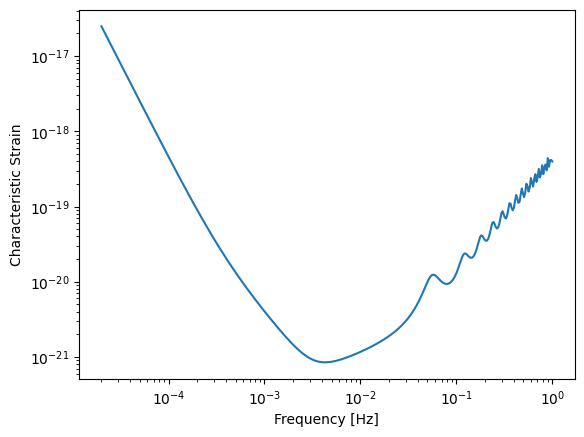

In [2]:
from matplotlib import pyplot as plt 
os.chdir('/home/hoelsczj/ASTR-8020/')
data = np.loadtxt('L3_noise.txt') 
fn_LISA = np.array(data[:, 0])
Sn_LISA = np.array(data[:, 1])
flow_LISA = np.min(fn_LISA) 
fmax_LISA = 0.5
df_LISA = 1e-5

plt.loglog(fn_LISA, np.sqrt(Sn_LISA*fn_LISA)) # plot LISA noise as strain (unitless)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain')
plt.show()

In [3]:
from pycbc.detector import Detector, get_available_detectors
import pycbc
from pycbc import waveform as waveform
import numpy as np
import pylab
import pycbc.psd
import math
from numpy import *
import scipy
from pycbc.filter import match, matched_filter, sigmasq, overlap_cplx
import matplotlib.pyplot as plt
from pycbc.detector import Detector
from pycbc.waveform import get_td_waveform
from scipy.interpolate import interp1d
import astropy.units as u
from astropy.coordinates import Distance
from tqdm import tqdm

import astropy.units as u
from astropy.cosmology import z_at_value, Planck13 #This refers to Planck results released in 2014, despite saying Planck13.
import numpy as np

def SNR(m1, m2, CosmicTime, inclination,spin1z,spin2z):
    # we convert cosmic time to redshift, then convert that to distance

    #Obtaining redshift from cosmic time:
    z=z_at_value(Planck13.age, CosmicTime*u.Gyr)  

    #Obtaining distance from redshift: 
    dl = Distance(unit=u.Mpc, z = z, cosmology = Planck13).value

    # Generating GW signals in frequency domain for massive black hole binary 

    df = df_LISA
    flow = flow_LISA
    fmax = fmax_LISA

    m1d=m1*(1+z) #Detector frame masses 
    m2d=m2*(1+z)

    [hp,hc] = waveform.get_fd_waveform(approximant="IMRPhenomXHM", 
                                                        mass1= m1d,  
                                                        mass2= m2d, 
                                                        f_lower= flow,
                                                        f_final= fmax,
                                                        delta_f= df,
                                                        distance=dl,
                                                        inclination=inclination,
                                                        coa_phase=0,
                                                        spin1z=spin1z,
                                                        spin2z=spin2z)
    

    fw = hp.sample_frequencies.data 
    hf = hp + hc
    
    # Compute SNR in LISA 

    flow = flow_LISA
    fmax = fmax_LISA
    hf = hf
    df = df

    psdlisa = pycbc.psd.from_numpy_arrays(fn_LISA,Sn_LISA,len(hf),df,flow)
    snr_sq = sigmasq(hf, psdlisa, low_frequency_cutoff=flow, high_frequency_cutoff=fmax)
    snr_SMBH_LISA = np.sqrt(snr_sq)
    return snr_SMBH_LISA,z
    
def SNRMinMax(m1value, m2value, CosmicTimeValue):
    N = 10
    spin_range = [-0.999,0.999]
    inclination_range = [0,np.pi]
    spin1zList = np.linspace(spin_range[0],spin_range[1],N) #linear distribution of spin values
    spin2zList = np.copy(spin1zList) #second mass will have copy spin
    inclinationList = np.linspace(inclination_range[0],inclination_range[1],N) # Inclination will go from 0 to pi 

    SNRList=[]
    for index1 in tqdm(range(len(spin1zList))):
        spin1=spin1zList[index1]
        for index2 in range(len(spin2zList)):
            spin2=spin2zList[index2]
            for index3 in range(len(inclinationList)):
                inclinationvalue=inclinationList[index3]
                SNRList.append(SNR(m1value, m2value, CosmicTimeValue, inclination=inclinationvalue
                                           ,spin1z=spin1,spin2z=spin2)[0])
    return np.min(SNRList), np.max(SNRList)


/home/hoelsczj/miniconda3/envs/SNR/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(True)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
<frozen importlib._bootstrap>:241: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 80 from C header, got 96 from PyObject


In [4]:
MinimumListCDM=[]
MaximumListCDM=[]
for i in range(0, len(GM7CDM_Cosmic_Time)):
    Minimum, Maximum = SNRMinMax(M1_GM7CDM[i], M2_GM7CDM[i], GM7CDM_Cosmic_Time[i])
    MinimumListCDM.append(Minimum)
    MaximumListCDM.append(Maximum)

100%|██████████| 10/10 [01:12<00:00,  7.26s/it]


In [5]:
MinimumListSIDM=[]
MaximumListSIDM=[]
for i in range(0, len(GM7SIDM_Cosmic_Time)):
    Minimum, Maximum = SNRMinMax(M1_GM7SIDM[i], M2_GM7SIDM[i], GM7SIDM_Cosmic_Time[i])
    MinimumListSIDM.append(Minimum)
    MaximumListSIDM.append(Maximum)

100%|██████████| 10/10 [01:13<00:00,  7.33s/it]


In [6]:
print(np.min(MinimumListCDM))
print(np.min(MinimumListSIDM))

48.86996680833983
52.445862225349885


/tmp/ipykernel_457688/3420688871.py:41: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


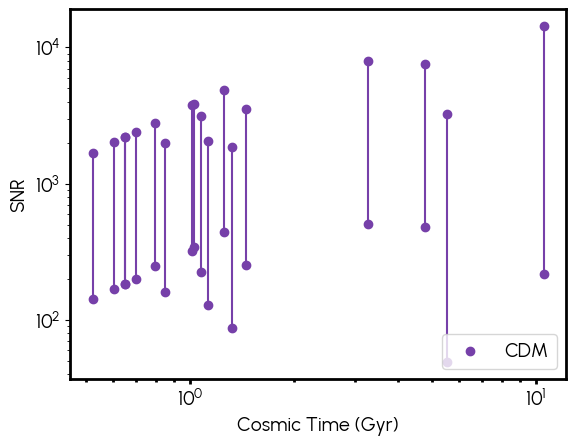

In [7]:
from matplotlib import font_manager


for fontpath in font_manager.findSystemFonts(fontpaths=None, fontext="ttf"):
    if 'Urbanist'.lower() in fontpath.lower():
        print(fontpath)

from matplotlib.font_manager import FontProperties

# !!! change it to your path
personal_path = "/home/hoelsczj/Library/static/"

# get normal font and store it in `urbanist-Light`
font_path = personal_path + "Urbanist-Regular.ttf"
font_manager.fontManager.addfont(font_path)
urbanist= FontProperties(fname=font_path)

# get bold font and store it in `urbanist_bold`
font_path = personal_path + "Urbanist-Bold.ttf"
font_manager.fontManager.addfont(font_path)
urbanist_bold = FontProperties(fname=font_path)

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams['font.sans-serif'] = urbanist.get_name()
SMALL_SIZE = 14
MEDIUM_SIZE = 14
BIGGER_SIZE = 14

plt.rc('font', family="urbanist", size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE, lw=2)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rcParams['xtick.minor.width']=2   
plt.rcParams['xtick.major.width']=2 
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

from pyfonts import load_google_font
from pypalettes import load_cmap
import pandas as pd
cmap = load_cmap("PurpleGreens")

plt.scatter(GM7CDM_Cosmic_Time,MinimumListCDM, color=cmap(1), label='CDM')
plt.scatter(GM7CDM_Cosmic_Time,MaximumListCDM, color=cmap(1))
plt.vlines(x = GM7CDM_Cosmic_Time, ymin = MinimumListCDM, ymax = MaximumListCDM,
           colors = cmap(1),
           )
plt.xlabel("Cosmic Time (Gyr)")
plt.ylabel("SNR")
plt.xscale("log")
plt.yscale("log")
plt.legend(loc='lower right')
os.chdir('/home/hoelsczj/SIDM_Paper_Runs')
plt.savefig('SNR_CDM.pdf')
plt.show()

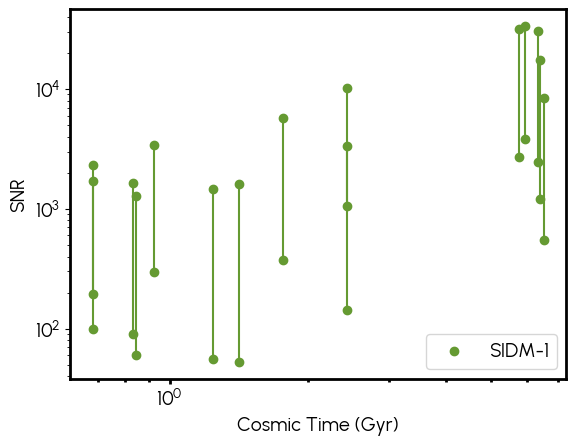

In [8]:
plt.scatter(GM7SIDM_Cosmic_Time,MinimumListSIDM, color=cmap(6), label = 'SIDM-1')
plt.scatter(GM7SIDM_Cosmic_Time,MaximumListSIDM, color=cmap(6))
plt.vlines(x = GM7SIDM_Cosmic_Time, ymin = MinimumListSIDM, ymax = MaximumListSIDM,
           colors = cmap(6),
           )
plt.xlabel("Cosmic Time (Gyr)")
plt.ylabel("SNR")
plt.xscale("log")
plt.yscale("log")
plt.legend(loc='lower right')
os.chdir('/home/hoelsczj/SIDM_Paper_Runs')
plt.savefig('SNR_SIDM.pdf')
plt.show()